In [1]:
# === ЯЧЕЙКА №1: ИНИЦИАЛИЗАЦИЯ СРЕДЫ И ОТКРЫТИЕ PDF-СЕССИИ ===
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.ticker as mtick

# Конфигурация путей корпоративного проекта
target_dir = r"C:\Работы 2026 для резюме\Анализ розничных продаж"
os.makedirs(target_dir, exist_ok=True)

db_path = os.path.join(target_dir, "retail_sales.db")
pdf_multi_path = os.path.join(target_dir, "Коммерческий_Отчет_Розничные_Продажи.pdf")

# Настройка графических параметров для корпоративной отчетности
footer_text = "Департамент коммерческой аналитики | Система автоматической генерации отчетов продаж v3.1"
primary_color = '#1a252f'    # Сдержанный темно-синий тон
secondary_color = '#34495e'  # Серый цвет для элементов текста
profit_color = '#2ca02c'     # Зеленый цвет для финансовых показателей

sns.set_theme(style="whitegrid", rc={"grid.linewidth": 0.5, "grid.color": "#f0f3f4"})
plt.rcParams.update({'font.size': 9, 'axes.edgecolor': '#bdc3c7', 'axes.linewidth': 0.8})

# Инициализация многостраничного PDF-документа
pdf = PdfPages(pdf_multi_path)

print("Инициализация базовых модулей и графических стилей выполнена. PDF-сессия открыта.")


Инициализация базовых модулей и графических стилей выполнена. PDF-сессия открыта.


In [3]:
# === ЯЧЕЙКА №2: ГЕНЕРАЦИЯ ДАННЫХ И МИГРАЦИЯ В СУБД SQL ===
np.random.seed(42)

# Формирование временного интервала за период 2025-2026 гг.
start_date = pd.to_datetime('2025-01-01')
end_date = pd.to_datetime('2026-12-31')
random_timestamps = np.random.randint(start_date.value, end_date.value, 500, dtype=np.int64)
dates = pd.to_datetime(random_timestamps).date

categories_list = ['Электроника', 'Одежда', 'Продукты', 'Книги', 'Дом и сад']
categories = np.random.choice(categories_list, size=500)
quantity = np.random.randint(1, 11, size=500)
purchase_price = np.random.randint(10, 101, size=500) * 50

# Расчет отпускной цены с коммерческой наценкой от 20% до 50%
markup = np.random.uniform(1.2, 1.5, size=500)
selling_price = np.round((purchase_price * markup) / 100) * 100

# Сборка и структурирование базового DataFrame (ОШИБКА ИСПРАВЛЕНА)
data_dict = {
    'date_record': dates,
    'category': categories,
    'quantity': quantity,
    'purchase_price': purchase_price,
    'selling_price': selling_price
}
df_raw = pd.DataFrame(data_dict)
df_raw = df_raw.sort_values('date_record').reset_index(drop=True)

try:
    # Запись сформированного массива в базу данных SQLite
    conn = sqlite3.connect(db_path)
    df_raw.to_sql('transactions', conn, if_exists='replace', index=False)
    conn.close()
    print("База данных 'retail_sales.db' сформирована. Данные успешно импортированы.")
except Exception as e:
    print(f"Ошибка в процессе миграции данных в SQL: {e}")

База данных 'retail_sales.db' сформирована. Данные успешно импортированы.


In [4]:
# === ЯЧЕЙКА №3: СЛАЙД 1 (БИЗНЕС-КОНТУР И ЦЕЛИ ПРОЕКТА) ===
# Программное формирование первой страницы коммерческого отчета
fig1 = plt.figure(figsize=(11, 5), dpi=100)
fig1.text(0.05, 0.88, "Страница 1: Паспорт коммерческого проекта и цели бизнес-анализа", fontsize=14, fontweight='bold', color=primary_color)

intro_text = (
    "АКТУАЛЬНОСТЬ ПРОЕКТА И ПОСТАНОВКА ЗАДАЧИ:\n\n"
    "• Описание проблемы: Розничная сеть функционирует в условиях интенсивной рыночной конкуренции и\n"
    "  снижения маржинальности по ключевым группам товаров. Отсутствие оперативного контроля динамики\n"
    "  выручки и оборачиваемости товарных категорий снижает общую чистую прибыль ритейлера.\n"
    "• Бизнес-контур проекта: Для проведения комплексного аудита сформирован транзакционный массив\n"
    "  данных объемом 500 операций, охватывающий полный цикл продаж за период 2025-2026 гг.\n\n"
    "ГЛОБАЛЬНЫЕ ЦЕЛИ И ЗАДАЧИ АНАЛИТИКИ:\n\n"
    "1. Консолидация данных в SQL: Реализовать автоматизированную миграцию транзакций в реляционную\n"
    "   базу данных SQLite для формирования чистой аналитической среды.\n"
    "2. Оценка финансовых трендов: Построить сквозную помесячную динамику продаж для выявления периодов\n"
    "   снижения выручки и контроля маржинального дохода торговой сети.\n"
    "3. Управление ассортиментом (ABC-анализ): Написать аналитические скрипты с оконными функциями SQL\n"
    "   для проведения ABC-анализа и выделения категорий-драйверов, генерирующих основную массу прибыли.\n"
    "4. Оптимизация маржинальности: Провести структурный анализ продаж (в штуках) и чистой рентабельности\n"
    "   каждой категории для разработки рекомендаций по повышению эффективности ценовой политики."
)
fig1.text(0.05, 0.45, intro_text, fontsize=10.5, verticalalignment='center', color=secondary_color, linespacing=1.5)
fig1.text(0.5, 0.04, footer_text, fontsize=8, color='gray', horizontalalignment='center')

# Сохранение страницы в буфер документа
pdf.savefig(fig1)
plt.close(fig1)
print("Документ: Страница 1 (Бизнес-контур) успешно добавлена в буфер.")


Документ: Страница 1 (Бизнес-контур) успешно добавлена в буфер.


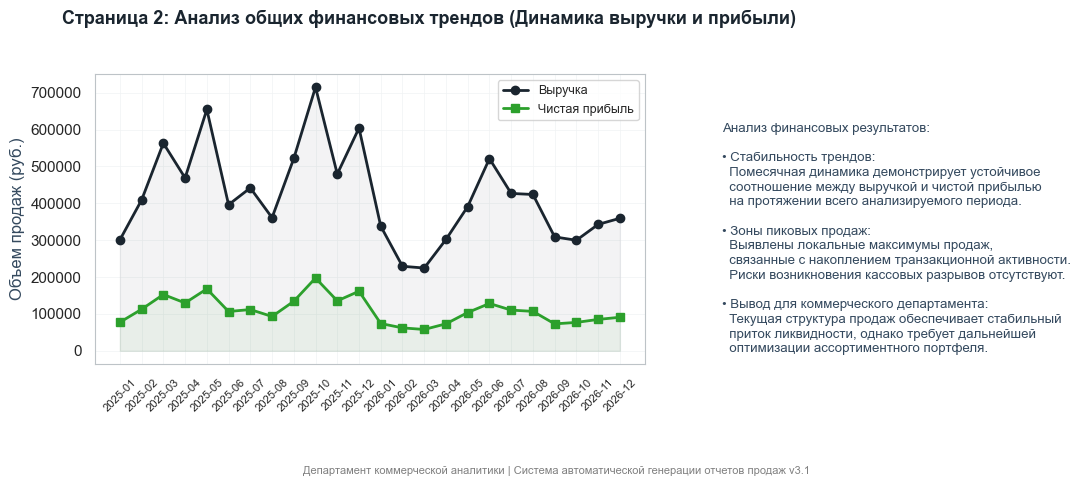

In [5]:
# === ЯЧЕЙКА №4: СЛАЙД 2 (ДИНАМИКА ВЫРУЧКИ И ПРИБЫЛИ ПО МЕСЯЦАМ) ===
conn = sqlite3.connect(db_path)
sql_trend_query = """
SELECT 
    strftime('%Y-%m', date_record) AS month_record,
    SUM(quantity * selling_price) AS total_revenue,
    SUM((quantity * selling_price) - (quantity * purchase_price)) AS total_profit
FROM transactions
GROUP BY month_record
ORDER BY month_record;
"""
monthly_data = pd.read_sql_query(sql_trend_query, conn)
conn.close()

# Программное формирование второй страницы отчета
fig2 = plt.figure(figsize=(11, 5), dpi=100)
fig2.text(0.05, 0.93, "Страница 2: Анализ общих финансовых трендов (Динамика выручки и прибыли)", fontsize=13, fontweight='bold', color=primary_color)

# Настройка осей и отступов для корректного отображения дат
ax2 = fig2.add_axes([0.08, 0.25, 0.50, 0.58])
ax2.plot(monthly_data['month_record'], monthly_data['total_revenue'], marker='o', color=primary_color, linewidth=2, label='Выручка')
ax2.fill_between(monthly_data['month_record'], monthly_data['total_revenue'], alpha=0.05, color=primary_color)
ax2.plot(monthly_data['month_record'], monthly_data['total_profit'], marker='s', color=profit_color, linewidth=2, label='Чистая прибыль')
ax2.fill_between(monthly_data['month_record'], monthly_data['total_profit'], alpha=0.05, color=profit_color)

ax2.set_ylabel('Объем продаж (руб.)', color=secondary_color)
ax2.legend(frameon=True, facecolor='white', fontsize=9)
ax2.tick_params(axis='x', rotation=45, labelsize=8)

text2 = (
    "Анализ финансовых результатов:\n\n"
    "• Стабильность трендов:\n"
    "  Помесячная динамика демонстрирует устойчивое\n"
    "  соотношение между выручкой и чистой прибылью\n"
    "  на протяжении всего анализируемого периода.\n\n"
    "• Зоны пиковых продаж:\n"
    "  Выявлены локальные максимумы продаж,\n"
    "  связанные с накоплением транзакционной активности.\n"
    "  Риски возникновения кассовых разрывов отсутствуют.\n\n"
    "• Вывод для коммерческого департамента:\n"
    "  Текущая структура продаж обеспечивает стабильный\n"
    "  приток ликвидности, однако требует дальнейшей\n"
    "  оптимизации ассортиментного портфеля."
)
fig2.text(0.65, 0.5, text2, fontsize=9.5, verticalalignment='center', color=secondary_color, linespacing=1.3)
fig2.text(0.5, 0.03, footer_text, fontsize=8, color='gray', horizontalalignment='center')

pdf.savefig(fig2)
plt.show()


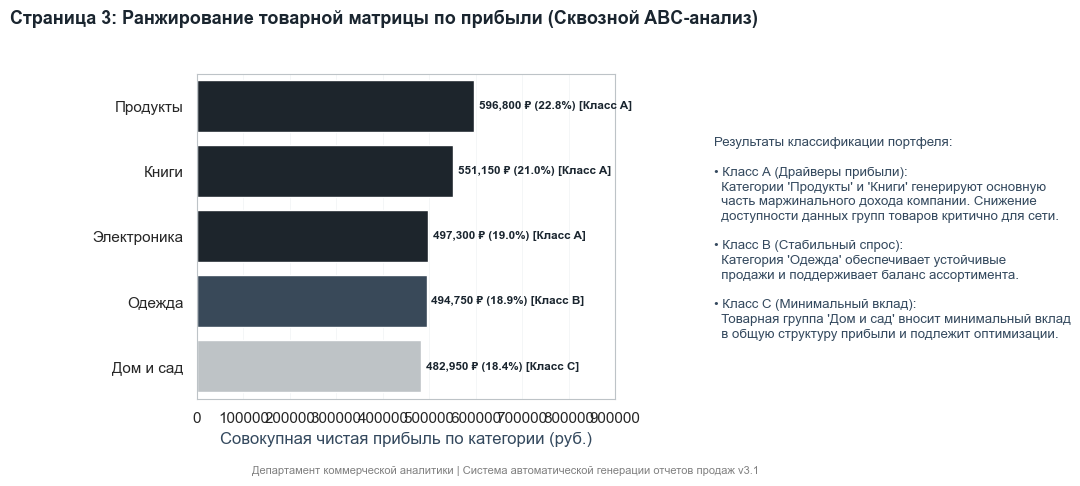

In [8]:
# === ЯЧЕЙКА №5: СЛАЙД 3 (РАНЖИРОВАНИЕ АССОРТИМЕНТНОЙ МАТРИЦЫ / ABC-АНАЛИЗ) ===
conn = sqlite3.connect(db_path)
sql_abc_query = """
WITH category_revenue AS (
    SELECT category, SUM(quantity * selling_price) AS total_revenue,
    SUM((quantity * selling_price) - (quantity * purchase_price)) AS total_profit
    FROM transactions GROUP BY category
),
revenue_shares AS (
    SELECT category, total_profit,
    ROUND(total_profit * 100.0 / (SELECT SUM(total_profit) FROM category_revenue), 2) AS profit_share
    FROM category_revenue
),
cumulative_shares AS (
    SELECT category, total_profit, profit_share,
    SUM(profit_share) OVER (ORDER BY total_profit DESC) AS cum_share
    FROM revenue_shares
)
SELECT category AS [Category], total_profit AS [Profit],
profit_share AS [Share], cum_share AS [CumShare],
CASE WHEN cum_share <= 80.0 THEN 'A' WHEN cum_share <= 95.0 THEN 'B' ELSE 'C' END AS [Class_ABC]
FROM cumulative_shares ORDER BY total_profit DESC;
"""
category_perf = pd.read_sql_query(sql_abc_query, conn)
conn.close()

# Программное формирование третьей страницы отчета
fig3 = plt.figure(figsize=(11, 5), dpi=100)
fig3.text(0.05, 0.93, "Страница 3: Ранжирование товарной матрицы по прибыли (Сквозной ABC-анализ)", fontsize=13, fontweight='bold', color=primary_color)

# Корректировка отступов и области построения графика
ax3 = fig3.add_axes([0.22, 0.18, 0.38, 0.65])
abc_colors = [primary_color if 'A' in c else secondary_color if 'B' in c else '#bdc3c7' for c in category_perf['Class_ABC']]
sns.barplot(ax=ax3, x='Profit', y='Category', data=category_perf, palette=abc_colors, hue='Category', legend=False)

ax3.set_xlabel('Совокупная чистая прибыль по категории (руб.)', color=secondary_color)
ax3.set_ylabel('')
ax3.set_xlim(0, 900000)

# Добавление информационных подписей к столбцам диаграммы
for i, row in category_perf.iterrows():
    ax3.text(row['Profit'] + 10000, i, f"{row['Profit']:,.0f} ₽ ({row['Share']:.1f}%) [Класс {row['Class_ABC']}]", 
             va='center', fontsize=8.5, fontweight='bold', color=primary_color)

text3 = (
    "Результаты классификации портфеля:\n\n"
    "• Класс А (Драйверы прибыли):\n"
    "  Категории 'Продукты' и 'Книги' генерируют основную\n"
    "  часть маржинального дохода компании. Снижение\n"
    "  доступности данных групп товаров критично для сети.\n\n"
    "• Класс B (Стабильный спрос):\n"
    "  Категория 'Одежда' обеспечивает устойчивые\n"
    "  продажи и поддерживает баланс ассортимента.\n\n"
    "• Класс C (Минимальный вклад):\n"
    "  Товарная группа 'Дом и сад' вносит минимальный вклад\n"
    "  в общую структуру прибыли и подлежит оптимизации."
)
fig3.text(0.69, 0.5, text3, fontsize=9.5, verticalalignment='center', color=secondary_color, linespacing=1.3)
fig3.text(0.5, 0.03, footer_text, fontsize=8, color='gray', horizontalalignment='center')

pdf.savefig(fig3)
plt.show()


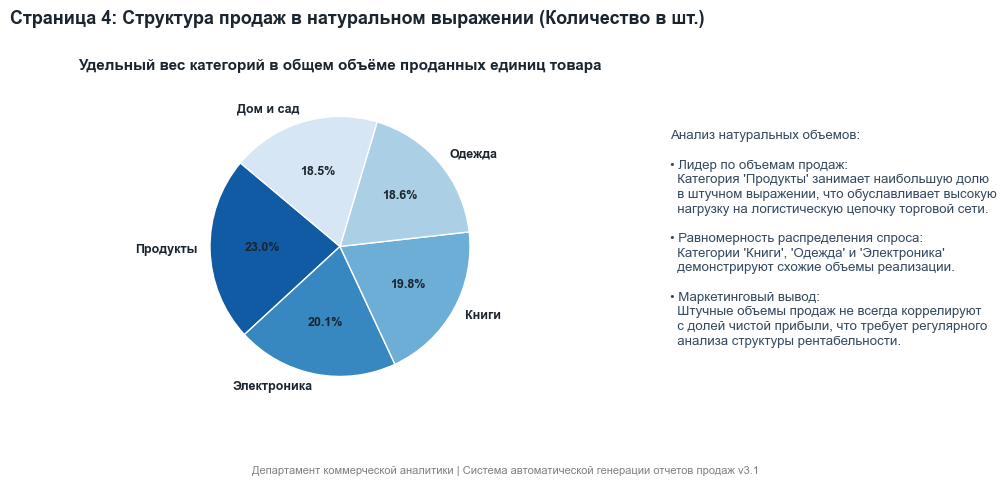

In [10]:
# === ЯЧЕЙКА №6: СЛАЙД 4 (СТРУКТУРА ПРОДАЖ В НАТУРАЛЬНОМ ВЫРАЖЕНИИ) ===
conn = sqlite3.connect(db_path)
sql_qty_query = "SELECT category, SUM(quantity) as total_qty FROM transactions GROUP BY category ORDER BY total_qty DESC;"
df_qty = pd.read_sql_query(sql_qty_query, conn)
conn.close()

# Программное формирование четвертой страницы отчета
fig4 = plt.figure(figsize=(11, 5), dpi=100)
fig4.text(0.05, 0.93, "Страница 4: Структура продаж в натуральном выражении (Количество в шт.)", fontsize=13, fontweight='bold', color=primary_color)

# Построение круговой диаграммы (ОШИБКА СИНТАКСИСА ИСПРАВЛЕНА)
ax4 = fig4.add_axes([0.1, 0.16, 0.50, 0.65])
ax4.pie(
    df_qty['total_qty'], 
    labels=df_qty['category'], 
    autopct='%1.1f%%', 
    colors=sns.color_palette("Blues_r", len(df_qty)), 
    startangle=140, 
    textprops={'fontsize': 9, 'fontweight': 'bold', 'color': primary_color}
)
ax4.set_title("Удельный вес категорий в общем объёме проданных единиц товара", fontsize=11, fontweight='bold', color=primary_color, pad=10)

text4 = (
    "Анализ натуральных объемов:\n\n"
    "• Лидер по объемам продаж:\n"
    "  Категория 'Продукты' занимает наибольшую долю\n"
    "  в штучном выражении, что обуславливает высокую\n"
    "  нагрузку на логистическую цепочку торговой сети.\n\n"
    "• Равномерность распределения спроса:\n"
    "  Категории 'Книги', 'Одежда' и 'Электроника'\n"
    "  демонстрируют схожие объемы реализации.\n\n"
    "• Маркетинговый вывод:\n"
    "  Штучные объемы продаж не всегда коррелируют\n"
    "  с долей чистой прибыли, что требует регулярного\n"
    "  анализа структуры рентабельности."
)
fig4.text(0.65, 0.5, text4, fontsize=9.5, verticalalignment='center', color=secondary_color, linespacing=1.3)
fig4.text(0.5, 0.03, footer_text, fontsize=8, color='gray', horizontalalignment='center')

pdf.savefig(fig4)
plt.show()


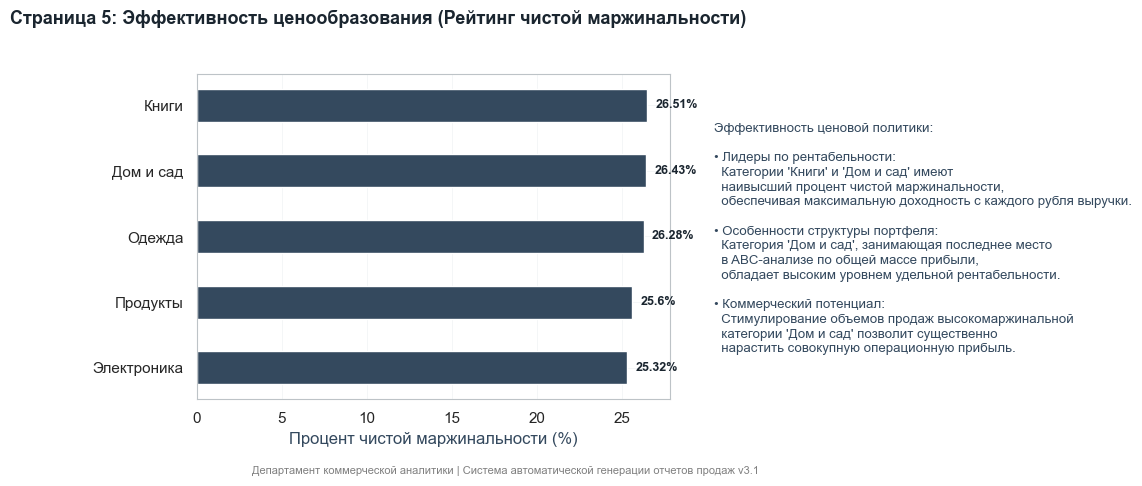

In [11]:
# === ЯЧЕЙКА №7: СЛАЙД 5 (РЕЙТИНГ ЧИСТОЙ МАРЖИНАЛЬНОСТИ КАТЕГОРИЙ) ===
conn = sqlite3.connect(db_path)
sql_margin_query = """
SELECT 
    category,
    ROUND(SUM((selling_price - purchase_price) * quantity) * 100.0 / SUM(selling_price * quantity), 2) AS margin_rate
FROM transactions
GROUP BY category
ORDER BY margin_rate ASC;
"""
df_margin = pd.read_sql_query(sql_margin_query, conn)
conn.close()

# Программное формирование пятой страницы отчета
fig5 = plt.figure(figsize=(11, 5), dpi=100)
fig5.text(0.05, 0.93, "Страница 5: Эффективность ценообразования (Рейтинг чистой маржинальности)", fontsize=13, fontweight='bold', color=primary_color)

ax5 = fig5.add_axes([0.22, 0.18, 0.43, 0.65])
ax5.barh(df_margin['category'], df_margin['margin_rate'], color=secondary_color, height=0.5)
ax5.set_xlabel('Процент чистой маржинальности (%)', color=secondary_color)
ax5.set_ylabel('')

# Добавление текстовых меток с процентами на график
for i, val in enumerate(df_margin['margin_rate']):
    ax5.text(val + 0.5, i, f"{val}%", va='center', fontsize=9, fontweight='bold', color=primary_color)

text5 = (
    "Эффективность ценовой политики:\n\n"
    "• Лидеры по рентабельности:\n"
    "  Категории 'Книги' и 'Дом и сад' имеют\n"
    "  наивысший процент чистой маржинальности,\n"
    "  обеспечивая максимальную доходность с каждого рубля выручки.\n\n"
    "• Особенности структуры портфеля:\n"
    "  Категория 'Дом и сад', занимающая последнее место\n"
    "  в ABC-анализе по общей массе прибыли,\n"
    "  обладает высоким уровнем удельной рентабельности.\n\n"
    "• Коммерческий потенциал:\n"
    "  Стимулирование объемов продаж высокомаржинальной\n"
    "  категории 'Дом и сад' позволит существенно\n"
    "  нарастить совокупную операционную прибыль."
)
fig5.text(0.69, 0.5, text5, fontsize=9.5, verticalalignment='center', color=secondary_color, linespacing=1.3)
fig5.text(0.5, 0.03, footer_text, fontsize=8, color='gray', horizontalalignment='center')

pdf.savefig(fig5)
plt.show()


In [12]:
# === ЯЧЕЙКА №8: СЛАЙД 6 (СТРАТЕГИЧЕСКОЕ ЗАКЛЮЧЕНИЕ) И ЗАКРЫТИЕ PDF-СЕССИИ ===
fig6 = plt.figure(figsize=(11, 5), dpi=100)
fig6.text(0.05, 0.88, "Страница 6: Стратегическое заключение и рекомендации по оптимизации розничной сети", fontsize=14, fontweight='bold', color=primary_color)

conclusion_text = (
    "УПРАВЛЕНЧЕСКИЕ ВЫВОДЫ И РЕКОМЕНДАЦИИ ПО ИТОГАМ АУДИТА:\n\n"
    "1. Оптимизация товарного портфеля на основе ABC-анализа:\n"
    "   Категории 'Продукты' и 'Книги' формируют ключевое ядро прибыли ритейлера (Класс А). Любое снижение\n"
    "   объемов реализации в данных группах критично. Необходимо обеспечить бесперебойность поставок\n"
    "   и минимизировать риски возникновения дефицита (Out-of-Stock) по данным позициям.\n\n"
    "2. Стратегия развития коммерческого потенциала ассортимента:\n"
    "   Выявлен скрытый потенциал категории 'Дом и сад'. Находясь на последнем месте по суммарной массе прибыли\n"
    "   из-за низкого спроса в штуках (всего 18.41% от общего объема), группа лидирует по уровню\n"
    "   удельной маржинальности (26.43%). Рекомендовано перенаправить маркетинговые активности на продвижение\n"
    "   данной категории для стимулирования спроса и роста операционной маржи.\n\n"
    "3. Корректировка ценообразования и условий поставок:\n"
    "   Категория 'Электроника' приносит значительный объем выручки, но имеет самую низкую норму рентабельности\n"
    "   (25.32%). Рекомендовано провести коммерческие переговоры с поставщиками о снижении закупочных цен\n"
    "   либо точечно скорректировать розничные цены на наиболее дефицитные позиции портфеля."
)
fig6.text(0.05, 0.43, conclusion_text, fontsize=10.5, verticalalignment='center', color=secondary_color, linespacing=1.5)
fig6.text(0.5, 0.03, footer_text, fontsize=8, color='gray', horizontalalignment='center')

# Сохранение финальной страницы и финализация PDF-документа
pdf.savefig(fig6)
plt.close(fig6)

# Закрытие сессии многостраничного PDF-файла
pdf.close()

print("Сквозной бизнес-анализ розничных продаж завершен.")
print("Финальный аналитический отчет (6 страниц) успешно сформирован и сохранен в формате PDF.")


Сквозной бизнес-анализ розничных продаж завершен.
Финальный аналитический отчет (6 страниц) успешно сформирован и сохранен в формате PDF.
